In [1]:
#1
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

DB_PATH = Path("../database/fno_stocks.db")

# ============================================================
# LOAD DATA
# ============================================================

conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query(
    """
    SELECT
        stock,
        symbol,
        contract,
        expiry,
        datetime,
        open,
        high,
        low,
        close,
        volume,
        open_interest
    FROM fno_stocks_data
    ORDER BY stock, expiry, datetime
    """,
    conn
)

conn.close()

# ============================================================
# DATETIME
# ============================================================

df["datetime"] = pd.to_datetime(df["datetime"])

# ============================================================
# BASIC CLEANING
# ============================================================

df = df.drop_duplicates(
    subset=[
        "stock",
        "symbol",
        "expiry",
        "datetime"
    ]
)

df = df.sort_values(
    [
        "stock",
        "expiry",
        "datetime"
    ]
).reset_index(drop=True)

print("Rows:", len(df))
print("Stocks:", df["stock"].nunique())
print("Contracts:", df["symbol"].nunique())

print()
print("Date range:")
print(df["datetime"].min())
print(df["datetime"].max())

df.head()

Rows: 6655642
Stocks: 210
Contracts: 629

Date range:
2026-07-01 09:15:00+05:30
2026-09-08 15:39:00+05:30


,stock,symbol,contract,expiry,datetime,open,high,low,close,volume,open_interest
0,360ONE,NSE:360ONE26SEPFUT,360ONE 29 Sep 26 FUT,2026-09-29,2026-07-08 15:00:00+05:30,1100.0,1100.0,1100.0,1100.0,500.0,0.0
1,360ONE,NSE:360ONE26SEPFUT,360ONE 29 Sep 26 FUT,2026-09-29,2026-07-08 15:01:00+05:30,1100.0,1100.0,1100.0,1100.0,0.0,0.0
2,360ONE,NSE:360ONE26SEPFUT,360ONE 29 Sep 26 FUT,2026-09-29,2026-07-08 15:02:00+05:30,1100.0,1100.0,1100.0,1100.0,0.0,0.0
3,360ONE,NSE:360ONE26SEPFUT,360ONE 29 Sep 26 FUT,2026-09-29,2026-07-08 15:03:00+05:30,1100.0,1100.0,1100.0,1100.0,0.0,0.0
4,360ONE,NSE:360ONE26SEPFUT,360ONE 29 Sep 26 FUT,2026-09-29,2026-07-08 15:04:00+05:30,1100.0,1100.0,1100.0,1100.0,0.0,0.0


In [2]:
#2 ============================================================
# CONTRACT-LEVEL ANALYSIS
# ============================================================

analysis = df.copy()

# Group by individual stock futures contract
group_cols = ["stock", "symbol", "expiry"]

# Previous candle values
analysis["prev_close"] = (
    analysis.groupby(group_cols)["close"].shift(1)
)

analysis["prev_oi"] = (
    analysis.groupby(group_cols)["open_interest"].shift(1)
)

analysis["prev_volume"] = (
    analysis.groupby(group_cols)["volume"].shift(1)
)

# ------------------------------------------------------------
# PRICE CHANGE
# ------------------------------------------------------------

analysis["price_change"] = (
    analysis["close"] - analysis["prev_close"]
)

analysis["price_change_pct"] = (
    analysis["price_change"]
    / analysis["prev_close"]
    * 100
)

# ------------------------------------------------------------
# OI CHANGE
# ------------------------------------------------------------

analysis["oi_change"] = (
    analysis["open_interest"]
    - analysis["prev_oi"]
)

analysis["oi_change_pct"] = (
    analysis["oi_change"]
    / analysis["prev_oi"]
    * 100
)

# ------------------------------------------------------------
# VOLUME CHANGE
# ------------------------------------------------------------

analysis["volume_change"] = (
    analysis["volume"]
    - analysis["prev_volume"]
)

analysis["volume_change_pct"] = (
    analysis["volume_change"]
    / analysis["prev_volume"]
    * 100
)

# ------------------------------------------------------------
# REMOVE INVALID FIRST ROWS
# ------------------------------------------------------------

analysis = analysis.dropna(
    subset=["prev_close", "prev_oi"]
).reset_index(drop=True)

print("Analysis rows:", len(analysis))

analysis[
    [
        "stock",
        "symbol",
        "expiry",
        "datetime",
        "close",
        "price_change",
        "price_change_pct",
        "open_interest",
        "oi_change",
        "oi_change_pct"
    ]
].head(10)

Analysis rows: 6655013


,stock,symbol,expiry,datetime,close,price_change,price_change_pct,open_interest,oi_change,oi_change_pct
0,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:01:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
1,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:02:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
2,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:03:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
3,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:04:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
4,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:05:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
5,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:06:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
6,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:07:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
7,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:08:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
8,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:09:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN
9,360ONE,NSE:360ONE26SEPFUT,2026-09-29,2026-07-08 15:10:00+05:30,1100.0,0.0,0.0,0.0,0.0,NaN


In [3]:
# ============================================================
# OI DATA QUALITY CHECK
# ============================================================

print("Total analysis rows:", len(analysis))

print()
print("OI = 0 rows:")
print((analysis["open_interest"] == 0).sum())

print()
print("OI > 0 rows:")
print((analysis["open_interest"] > 0).sum())

print()
print("OI missing rows:")
print(analysis["open_interest"].isna().sum())

print()
print("OI statistics:")
print(analysis["open_interest"].describe())

print()
print("Sample rows where OI > 0:")

analysis.loc[
    analysis["open_interest"] > 0,
    [
        "stock",
        "symbol",
        "datetime",
        "close",
        "open_interest",
        "oi_change"
    ]
].head(10)

Total analysis rows: 6655013

OI = 0 rows:
90003

OI > 0 rows:
6564512

OI missing rows:
0

OI statistics:
count    6.655013e+06
mean     1.074543e+07
std      5.737006e+07
min     -2.139567e+09
25%      4.400000e+04
50%      3.442250e+05
75%      3.154725e+06
max      2.145108e+09
Name: open_interest, dtype: float64

Sample rows where OI > 0:


,stock,symbol,datetime,close,open_interest,oi_change
29,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:51:00+05:30,1110.0,500.0,500.0
30,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:52:00+05:30,1110.0,500.0,0.0
31,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:53:00+05:30,1110.0,500.0,0.0
32,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:54:00+05:30,1110.0,500.0,0.0
33,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:55:00+05:30,1110.0,500.0,0.0
34,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:56:00+05:30,1110.0,500.0,0.0
35,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:57:00+05:30,1110.0,500.0,0.0
36,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:58:00+05:30,1110.0,500.0,0.0
37,360ONE,NSE:360ONE26SEPFUT,2026-07-09 09:59:00+05:30,1110.0,500.0,0.0
38,360ONE,NSE:360ONE26SEPFUT,2026-07-09 10:00:00+05:30,1110.0,500.0,0.0


In [5]:
#3 ============================================================
# NEGATIVE OI CHECK
# ============================================================

negative_oi = analysis[
    analysis["open_interest"] < 0
]

print("Negative OI rows:", len(negative_oi))

print()
print("Negative OI percentage:")
print(
    round(
        len(negative_oi) / len(analysis) * 100,
        4
    ),
    "%"
)

print()
print("Negative OI sample:")

negative_oi[
    [
        "stock",
        "symbol",
        "expiry",
        "datetime",
        "close",
        "open_interest",
        "oi_change"
    ]
].head(20)

Negative OI rows: 498

Negative OI percentage:
0.0075 %

Negative OI sample:


,stock,symbol,expiry,datetime,close,open_interest,oi_change
2790954,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:50:00+05:30,14.09,-2.139567e+09,-4.284675e+09
2790955,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:51:00+05:30,14.10,-2.136708e+09,2.859000e+06
2790956,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:52:00+05:30,14.10,-2.133635e+09,3.073425e+06
2790957,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:53:00+05:30,14.10,-2.131562e+09,2.072775e+06
2790958,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:54:00+05:30,14.11,-2.130204e+09,1.358025e+06
2790959,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:55:00+05:30,14.12,-2.128489e+09,1.715400e+06
2790960,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:56:00+05:30,14.11,-2.127059e+09,1.429500e+06
2790961,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:57:00+05:30,14.12,-2.126273e+09,7.862250e+05
2790962,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:58:00+05:30,14.12,-2.124700e+09,1.572450e+06
2790963,IDEA,NSE:IDEA26SEPFUT,2026-09-29,2026-08-21 11:59:00+05:30,14.10,-2.122628e+09,2.072775e+06


In [7]:
#4 ============================================================
# VALID OI FOR ANALYSIS
# ============================================================

# Keep raw database untouched.
# OI <= 0 is not valid for OI-based analysis.

analysis["valid_oi"] = analysis["open_interest"].where(
    analysis["open_interest"] > 0
)

# Recalculate OI change using only valid OI observations
analysis["valid_prev_oi"] = (
    analysis.groupby(
        ["stock", "symbol", "expiry"]
    )["valid_oi"].shift(1)
)

analysis["valid_oi_change"] = (
    analysis["valid_oi"]
    - analysis["valid_prev_oi"]
)

analysis["valid_oi_change_pct"] = (
    analysis["valid_oi_change"]
    / analysis["valid_prev_oi"]
    * 100
)

print("Valid OI rows:",
      analysis["valid_oi"].notna().sum())

print("Invalid OI rows:",
      analysis["valid_oi"].isna().sum())

print("Negative OI rows:",
      (analysis["open_interest"] < 0).sum())

print("Zero OI rows:",
      (analysis["open_interest"] == 0).sum())

Valid OI rows: 6564512
Invalid OI rows: 90501
Negative OI rows: 498
Zero OI rows: 90003


In [8]:
#5 ============================================================
# F&O POSITION CLASSIFICATION
# ============================================================

def classify_position(row):

    price_change = row["price_change"]
    oi_change = row["valid_oi_change"]

    # Cannot classify without valid OI
    if pd.isna(oi_change):
        return "No OI Data"

    # Price UP + OI UP
    if price_change > 0 and oi_change > 0:
        return "Long Buildup"

    # Price DOWN + OI UP
    elif price_change < 0 and oi_change > 0:
        return "Short Buildup"

    # Price UP + OI DOWN
    elif price_change > 0 and oi_change < 0:
        return "Short Covering"

    # Price DOWN + OI DOWN
    elif price_change < 0 and oi_change < 0:
        return "Long Unwinding"

    # Price/OI unchanged
    else:
        return "Neutral"


analysis["position"] = analysis.apply(
    classify_position,
    axis=1
)

# ============================================================
# CLASSIFICATION SUMMARY
# ============================================================

print("Position classification:")
print()

print(
    analysis["position"]
    .value_counts()
)

print()
print("Percentage:")
print(
    (
        analysis["position"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Position classification:

position
Neutral           5398280
Short Buildup      484024
Long Buildup       426615
Short Covering     136901
Long Unwinding     117861
No OI Data          91332
Name: count, dtype: int64

Percentage:
position
Neutral           81.12
Short Buildup      7.27
Long Buildup       6.41
Short Covering     2.06
Long Unwinding     1.77
No OI Data         1.37
Name: proportion, dtype: float64


In [9]:
# ============================================================
# 6. STOCK FUTURES ANALYSIS SELECTOR
# ============================================================

available_stocks = sorted(
    analysis["stock"].dropna().unique()
)

print("=" * 60)
print("STOCK FUTURES ANALYSIS")
print("=" * 60)

print(f"\nAvailable stocks: {len(available_stocks)}")

# ============================================================
# 1. STOCK SELECTION
# ============================================================

while True:

    stock_input = input(
        "\nEnter stock symbol "
        "(example: RELIANCE, TCS, INFY): "
    ).strip().upper()

    if stock_input in available_stocks:
        selected_stock = stock_input
        break

    print(
        f"'{stock_input}' not found. "
        "Please enter a valid stock symbol."
    )

print(f"\nSelected Stock: {selected_stock}")

# ============================================================
# 2. ANALYSIS MODE
# ============================================================

print("\nAnalysis Mode:")
print("1. Individual Contract")
print("2. Cumulative (Current + Next + Far)")

while True:

    mode_input = input(
        "\nSelect analysis mode (1-2): "
    ).strip()

    if mode_input == "1":

        analysis_mode = "Individual"
        break

    elif mode_input == "2":

        analysis_mode = "Cumulative"
        break

    print("Invalid selection. Enter 1 or 2.")

print(
    f"\nAnalysis Mode: {analysis_mode}"
)

# ============================================================
# 3. CONTRACT SELECTION — INDIVIDUAL ONLY
# ============================================================

if analysis_mode == "Individual":

    stock_contracts = (
        analysis[
            analysis["stock"] == selected_stock
        ][
            ["symbol", "expiry"]
        ]
        .drop_duplicates()
        .sort_values("expiry")
        .reset_index(drop=True)
    )

    print("\nAvailable contracts:")

    for i, (_, row) in enumerate(
        stock_contracts.iterrows(),
        start=1
    ):

        print(
            f"{i}. "
            f"{row['expiry']} → "
            f"{row['symbol']}"
        )

    while True:

        contract_input = input(
            f"\nSelect contract (1-{len(stock_contracts)}): "
        ).strip()

        if contract_input.isdigit():

            contract_choice = int(contract_input)

            if 1 <= contract_choice <= len(stock_contracts):
                break

        print(
            f"Invalid contract. "
            f"Please enter 1-{len(stock_contracts)}."
        )

    selected_contract = stock_contracts.iloc[
        contract_choice - 1
    ]

    selected_symbol = selected_contract["symbol"]
    selected_expiry = selected_contract["expiry"]

    print(
        f"\nSelected Contract: {selected_symbol}"
    )

# ============================================================
# 4. CUMULATIVE CONTRACTS
# ============================================================

else:

    stock_contracts = (
        analysis[
            analysis["stock"] == selected_stock
        ][
            ["symbol", "expiry"]
        ]
        .drop_duplicates()
        .sort_values("expiry")
        .reset_index(drop=True)
    )

    cumulative_contracts = (
        stock_contracts
        .head(3)
        .copy()
    )

    print("\nContracts included:")

    for _, row in cumulative_contracts.iterrows():

        print(
            f"  {row['expiry']} → "
            f"{row['symbol']}"
        )

# ============================================================
# 5. TIMEFRAME SELECTION
# ============================================================

timeframes = [
    "5min",
    "15min",
    "30min",
    "1h",
    "4h",
    "1D",
    "1W"
]

print("\nAvailable timeframes:")

for i, tf in enumerate(
    timeframes,
    start=1
):

    print(f"{i}. {tf}")

while True:

    tf_input = input(
        "\nEnter timeframe number (1-7): "
    ).strip()

    if tf_input.isdigit():

        number = int(tf_input)

        if 1 <= number <= len(timeframes):

            selected_timeframe = (
                timeframes[number - 1]
            )

            break

    print(
        "Invalid selection. "
        "Enter a number from 1 to 7."
    )

print(
    f"\nSelected timeframe: "
    f"{selected_timeframe}"
)

print("=" * 60)

STOCK FUTURES ANALYSIS

Available stocks: 210

Selected Stock: TCS

Analysis Mode:
1. Individual Contract
2. Cumulative (Current + Next + Far)

Analysis Mode: Individual

Available contracts:
1. 2026-09-29 → NSE:TCS26SEPFUT
2. 2026-10-27 → NSE:TCS26OCTFUT
3. 2026-11-23 → NSE:TCS26NOVFUT

Selected Contract: NSE:TCS26SEPFUT

Available timeframes:
1. 5min
2. 15min
3. 30min
4. 1h
5. 4h
6. 1D
7. 1W

Selected timeframe: 1D


In [10]:
#6 ============================================================
# STOCK FUTURES ANALYSIS SELECTOR
# ============================================================

available_stocks = sorted(
    analysis["stock"].dropna().unique()
)

print("=" * 60)
print("STOCK FUTURES ANALYSIS")
print("=" * 60)

print(f"\nAvailable stocks: {len(available_stocks)}")

# ------------------------------------------------------------
# STOCK SELECTION
# ------------------------------------------------------------

while True:

    stock_input = input(
        "\nEnter stock symbol "
        "(example: RELIANCE, TCS, INFY): "
    ).strip().upper()

    if stock_input in available_stocks:
        selected_stock = stock_input
        break

    print(
        f"'{stock_input}' not found. "
        "Please enter a valid stock symbol."
    )

print(f"\nSelected Stock: {selected_stock}")

# ------------------------------------------------------------
# CONTRACT SELECTION
# ------------------------------------------------------------

stock_contracts = (
    analysis[
        analysis["stock"] == selected_stock
    ][
        ["symbol", "expiry"]
    ]
    .drop_duplicates()
    .sort_values("expiry")
    .reset_index(drop=True)
)

print("\nAvailable contracts:")

for i, (_, row) in enumerate(
    stock_contracts.iterrows(),
    start=1
):
    print(
        f"{i}. "
        f"{row['expiry']}  →  "
        f"{row['symbol']}"
    )

while True:

    contract_input = input(
        "\nSelect contract (1, 2, 3): "
    ).strip()

    try:
        contract_choice = int(contract_input)

        if 1 <= contract_choice <= len(stock_contracts):
            break

    except ValueError:
        pass

    print("Invalid contract. Please enter 1, 2, or 3.")

selected_contract = stock_contracts.iloc[
    contract_choice - 1
]

selected_symbol = selected_contract["symbol"]
selected_expiry = selected_contract["expiry"]

print(
    f"\nSelected contract: {selected_symbol}"
)

# ------------------------------------------------------------
# TIMEFRAME SELECTION
# ------------------------------------------------------------

timeframes = [
    "5min",
    "15min",
    "30min",
    "1h",
    "4h",
    "1D",
    "1W"
]

print("\nAvailable timeframes:")

for i, tf in enumerate(timeframes, start=1):
    print(f"{i}. {tf}")

while True:

    tf_input = input(
        "\nEnter timeframe number (1-7): "
    ).strip()

    if tf_input.isdigit():

        number = int(tf_input)

        if 1 <= number <= len(timeframes):
            selected_timeframe = timeframes[number - 1]
            break

    print("Invalid selection. Enter a number from 1 to 7.")

print(
    f"\nSelected timeframe: {selected_timeframe}"
)

print("=" * 60)


STOCK FUTURES ANALYSIS

Available stocks: 210

Selected Stock: TCS

Available contracts:
1. 2026-09-29  →  NSE:TCS26SEPFUT
2. 2026-10-27  →  NSE:TCS26OCTFUT
3. 2026-11-23  →  NSE:TCS26NOVFUT

Selected contract: NSE:TCS26SEPFUT

Available timeframes:
1. 5min
2. 15min
3. 30min
4. 1h
5. 4h
6. 1D
7. 1W

Selected timeframe: 1D


In [11]:
#7 ============================================================
# SELECTED CONTRACT DATA
# ============================================================

selected_data = df[
    (df["stock"] == selected_stock) &
    (df["symbol"] == selected_symbol) &
    (df["expiry"] == selected_expiry)
].copy()

selected_data = selected_data.sort_values("datetime")

print("=" * 60)
print("SELECTED CONTRACT")
print("=" * 60)

print(f"Stock      : {selected_stock}")
print(f"Contract   : {selected_symbol}")
print(f"Expiry     : {selected_expiry}")
print(f"Timeframe  : {selected_timeframe}")

print()
print("1-minute rows:", len(selected_data))
print("Start:", selected_data["datetime"].min())
print("End  :", selected_data["datetime"].max())

SELECTED CONTRACT
Stock      : TCS
Contract   : NSE:TCS26SEPFUT
Expiry     : 2026-09-29
Timeframe  : 1D

1-minute rows: 19010
Start: 2026-07-01 09:18:00+05:30
End  : 2026-09-08 15:39:00+05:30


In [12]:
# 8============================================================
# RESAMPLE OHLC + VOLUME + OI
# ============================================================

selected_data = selected_data.copy()

selected_data = selected_data.set_index("datetime")

# ------------------------------------------------------------
# RESAMPLE
# ------------------------------------------------------------

resampled = (
    selected_data
    .resample(
        selected_timeframe,
        origin="start_day",
        offset="9h15min"
    )
    .agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum",
        "open_interest": "last"
    })
)

# ------------------------------------------------------------
# REMOVE EMPTY CANDLES
# ------------------------------------------------------------

resampled = resampled.dropna(
    subset=["open", "high", "low", "close"]
)

# ------------------------------------------------------------
# DAILY / WEEKLY HANDLING
# ------------------------------------------------------------

if selected_timeframe in ["1D", "1W"]:

    # Daily/weekly candles are already session-based
    # and must NOT be filtered by candle timestamp.

    pass

else:

    # Intraday candles:
    # keep only NSE trading session

    resampled = resampled[
        (
            resampled.index.time >=
            pd.Timestamp("09:15").time()
        )
        &
        (
            resampled.index.time <=
            pd.Timestamp("15:30").time()
        )
    ]

# ------------------------------------------------------------
# RESET INDEX
# ------------------------------------------------------------

resampled = resampled.reset_index()

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 60)
print("RESAMPLED DATA")
print("=" * 60)

print("Stock     :", selected_stock)
print("Contract  :", selected_symbol)
print("Timeframe :", selected_timeframe)

print()
print("Candles:", len(resampled))

print(
    "Start:",
    resampled["datetime"].min()
)

print(
    "End  :",
    resampled["datetime"].max()
)

resampled.tail(10)

RESAMPLED DATA
Stock     : TCS
Contract  : NSE:TCS26SEPFUT
Timeframe : 1D

Candles: 50
Start: 2026-07-01 00:00:00+05:30
End  : 2026-09-08 00:00:00+05:30


/tmp/ipykernel_13030/2848117390.py:15: RuntimeWarning: The 'offset' keyword does not take effect when resampling with a 'freq' that is not Tick-like (h, m, s, ms, us, ns)
  .resample(


,datetime,open,high,low,close,volume,open_interest
40,2026-08-26 00:00:00+05:30,2317.0,2319.8,2282.5,2290.0,1472625.0,31407525.0
41,2026-08-27 00:00:00+05:30,2285.0,2295.2,2260.6,2270.0,1274400.0,31634100.0
42,2026-08-28 00:00:00+05:30,2285.0,2366.8,2280.0,2354.0,3922650.0,31078800.0
43,2026-08-31 00:00:00+05:30,2349.0,2356.6,2322.2,2342.0,1615725.0,30716325.0
44,2026-09-01 00:00:00+05:30,2355.1,2379.1,2332.0,2360.5,2203650.0,30427425.0
45,2026-09-02 00:00:00+05:30,2345.6,2374.0,2312.6,2346.3,1867050.0,29723175.0
46,2026-09-03 00:00:00+05:30,2355.8,2358.8,2323.7,2336.7,1226925.0,29722275.0
47,2026-09-04 00:00:00+05:30,2340.5,2378.6,2316.7,2319.3,1265850.0,29277450.0
48,2026-09-07 00:00:00+05:30,2310.0,2311.7,2268.0,2275.0,1431225.0,29467125.0
49,2026-09-08 00:00:00+05:30,2285.0,2285.0,2250.1,2271.9,1386000.0,29497275.0


In [13]:
#9 ============================================================
# RESAMPLE SELECTED CONTRACT
# ============================================================

# Always rebuild selected_data from the original df
# so this cell can be safely re-run.

selected_data = df[
    (df["stock"] == selected_stock) &
    (df["symbol"] == selected_symbol) &
    (df["expiry"] == selected_expiry)
].copy()

selected_data = selected_data.sort_values("datetime")

selected_data = selected_data.set_index("datetime")

# ------------------------------------------------------------
# RESAMPLE
# ------------------------------------------------------------

if selected_timeframe in ["1D", "1W"]:

    resampled = (
        selected_data
        .resample(selected_timeframe)
        .agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum",
            "open_interest": "last"
        })
    )

else:

    resampled = (
        selected_data
        .resample(
            selected_timeframe,
            origin="start_day",
            offset="9h15min"
        )
        .agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum",
            "open_interest": "last"
        })
    )

# ------------------------------------------------------------
# REMOVE EMPTY CANDLES
# ------------------------------------------------------------

resampled = resampled.dropna(
    subset=[
        "open",
        "high",
        "low",
        "close"
    ]
)

# ------------------------------------------------------------
# INTRADAY SESSION FILTER
# ------------------------------------------------------------

if selected_timeframe not in ["1D", "1W"]:

    resampled = resampled[
        (
            resampled.index.time >=
            pd.Timestamp("09:15").time()
        )
        &
        (
            resampled.index.time <=
            pd.Timestamp("15:30").time()
        )
    ]

# ------------------------------------------------------------
# RESET INDEX
# ------------------------------------------------------------

resampled = resampled.reset_index()

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 60)
print("RESAMPLED DATA")
print("=" * 60)

print("Stock     :", selected_stock)
print("Contract  :", selected_symbol)
print("Timeframe :", selected_timeframe)

print()
print("Candles:", len(resampled))
print("Start:", resampled["datetime"].min())
print("End  :", resampled["datetime"].max())

resampled.tail(10)

RESAMPLED DATA
Stock     : TCS
Contract  : NSE:TCS26SEPFUT
Timeframe : 1D

Candles: 50
Start: 2026-07-01 00:00:00+05:30
End  : 2026-09-08 00:00:00+05:30


,datetime,open,high,low,close,volume,open_interest
40,2026-08-26 00:00:00+05:30,2317.0,2319.8,2282.5,2290.0,1472625.0,31407525.0
41,2026-08-27 00:00:00+05:30,2285.0,2295.2,2260.6,2270.0,1274400.0,31634100.0
42,2026-08-28 00:00:00+05:30,2285.0,2366.8,2280.0,2354.0,3922650.0,31078800.0
43,2026-08-31 00:00:00+05:30,2349.0,2356.6,2322.2,2342.0,1615725.0,30716325.0
44,2026-09-01 00:00:00+05:30,2355.1,2379.1,2332.0,2360.5,2203650.0,30427425.0
45,2026-09-02 00:00:00+05:30,2345.6,2374.0,2312.6,2346.3,1867050.0,29723175.0
46,2026-09-03 00:00:00+05:30,2355.8,2358.8,2323.7,2336.7,1226925.0,29722275.0
47,2026-09-04 00:00:00+05:30,2340.5,2378.6,2316.7,2319.3,1265850.0,29277450.0
48,2026-09-07 00:00:00+05:30,2310.0,2311.7,2268.0,2275.0,1431225.0,29467125.0
49,2026-09-08 00:00:00+05:30,2285.0,2285.0,2250.1,2271.9,1386000.0,29497275.0


In [14]:
# 10 ============================================================
# TIMEFRAME-BASED F&O ANALYSIS
# ============================================================

tf_analysis = resampled.copy()

# ------------------------------------------------------------
# PREVIOUS CLOSE
# ------------------------------------------------------------

tf_analysis["prev_close"] = (
    tf_analysis["close"].shift(1)
)

# ------------------------------------------------------------
# VALID OI
# ------------------------------------------------------------

tf_analysis["valid_oi"] = (
    tf_analysis["open_interest"]
    .where(tf_analysis["open_interest"] > 0)
)

tf_analysis["prev_oi"] = (
    tf_analysis["valid_oi"].shift(1)
)

# ------------------------------------------------------------
# PRICE CHANGE
# ------------------------------------------------------------

tf_analysis["price_change"] = (
    tf_analysis["close"]
    - tf_analysis["prev_close"]
)

tf_analysis["price_change_pct"] = (
    tf_analysis["price_change"]
    / tf_analysis["prev_close"]
    * 100
)

# ------------------------------------------------------------
# OI CHANGE
# ------------------------------------------------------------

tf_analysis["oi_change"] = (
    tf_analysis["valid_oi"]
    - tf_analysis["prev_oi"]
)

tf_analysis["oi_change_pct"] = (
    tf_analysis["oi_change"]
    / tf_analysis["prev_oi"]
    * 100
)

# ------------------------------------------------------------
# POSITION CLASSIFICATION
# ------------------------------------------------------------

def classify_position(row):

    price_change = row["price_change"]
    oi_change = row["oi_change"]

    if pd.isna(oi_change):
        return "No OI Data"

    if price_change > 0 and oi_change > 0:
        return "Long Buildup"

    elif price_change < 0 and oi_change > 0:
        return "Short Buildup"

    elif price_change > 0 and oi_change < 0:
        return "Short Covering"

    elif price_change < 0 and oi_change < 0:
        return "Long Unwinding"

    else:
        return "Neutral"


tf_analysis["position"] = (
    tf_analysis.apply(
        classify_position,
        axis=1
    )
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("=" * 60)
print("F&O POSITION ANALYSIS")
print("=" * 60)

print(f"Stock     : {selected_stock}")
print(f"Contract  : {selected_symbol}")
print(f"Timeframe : {selected_timeframe}")

print()
print("Position summary:")
print(
    tf_analysis["position"].value_counts()
)

print()
print("Recent candles:")

tf_analysis[
    [
        "datetime",
        "close",
        "volume",
        "open_interest",
        "price_change_pct",
        "oi_change_pct",
        "position"
    ]
].tail(15)

F&O POSITION ANALYSIS
Stock     : TCS
Contract  : NSE:TCS26SEPFUT
Timeframe : 1D

Position summary:
position
Short Buildup     21
Long Buildup      18
Short Covering     6
Long Unwinding     4
No OI Data         1
Name: count, dtype: int64

Recent candles:


,datetime,close,volume,open_interest,price_change_pct,oi_change_pct,position
35,2026-08-19 00:00:00+05:30,2307.2,2267325.0,4007025.0,0.265091,58.471258,Long Buildup
36,2026-08-20 00:00:00+05:30,2307.4,13763925.0,15208875.0,0.008669,279.555281,Long Buildup
37,2026-08-21 00:00:00+05:30,2310.3,8933850.0,22119975.0,0.125683,45.441231,Long Buildup
38,2026-08-24 00:00:00+05:30,2314.9,7719075.0,28378800.0,0.199108,28.294901,Long Buildup
39,2026-08-25 00:00:00+05:30,2304.2,5285700.0,31323375.0,-0.462223,10.375967,Short Buildup
40,2026-08-26 00:00:00+05:30,2290.0,1472625.0,31407525.0,-0.616266,0.268649,Short Buildup
41,2026-08-27 00:00:00+05:30,2270.0,1274400.0,31634100.0,-0.873362,0.721404,Short Buildup
42,2026-08-28 00:00:00+05:30,2354.0,3922650.0,31078800.0,3.700441,-1.755384,Short Covering
43,2026-08-31 00:00:00+05:30,2342.0,1615725.0,30716325.0,-0.509771,-1.166310,Long Unwinding
44,2026-09-01 00:00:00+05:30,2360.5,2203650.0,30427425.0,0.789923,-0.940542,Short Covering


/tmp/ipykernel_13030/1845938708.py:178: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13030/1845938708.py:178: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13030/1845938708.py:178: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13030/1845938708.py:178: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/manish/trading_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/manish/trading_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

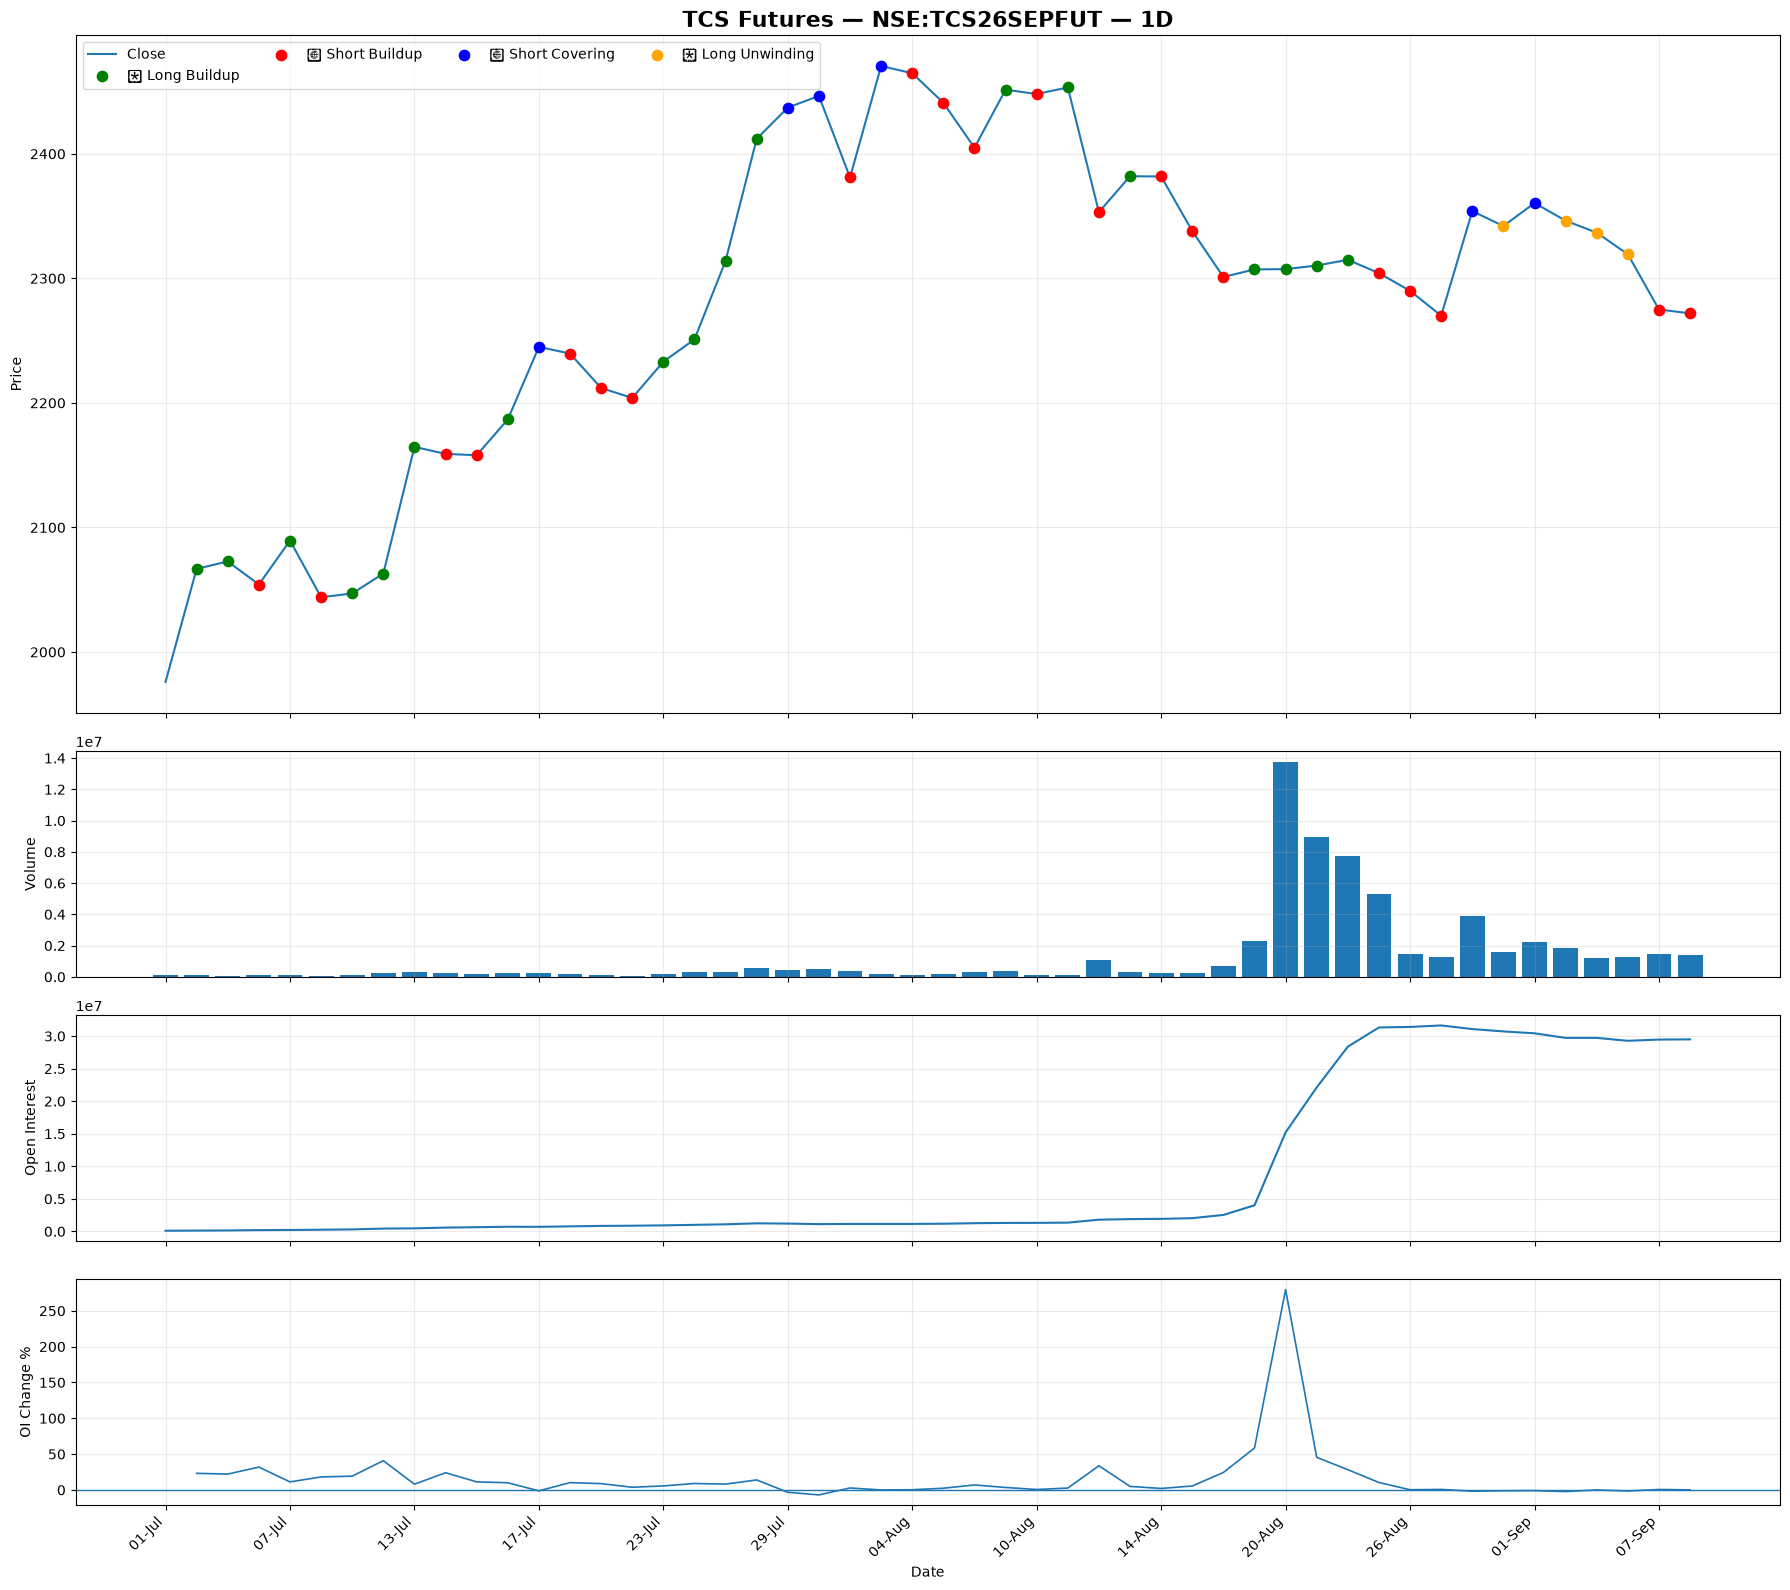

In [15]:
#11 ============================================================
# STOCK FUTURES DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(18, 16),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1, 1, 1]
    }
)

# ============================================================
# X-AXIS
# ============================================================

x = np.arange(len(tf_analysis))

# ============================================================
# PRICE
# ============================================================

ax = axes[0]

ax.plot(
    x,
    tf_analysis["close"],
    linewidth=1.5,
    label="Close"
)

# ------------------------------------------------------------
# POSITION DOTS
# ------------------------------------------------------------

position_markers = {
    "Long Buildup": "o",
    "Short Buildup": "o",
    "Short Covering": "o",
    "Long Unwinding": "o"
}

position_colors = {
    "Long Buildup": "green",
    "Short Buildup": "red",
    "Short Covering": "blue",
    "Long Unwinding": "orange"
}

position_labels = {
    "Long Buildup": "🟢 Long Buildup",
    "Short Buildup": "🔴 Short Buildup",
    "Short Covering": "🔵 Short Covering",
    "Long Unwinding": "🟠 Long Unwinding"
}

for position in position_colors:

    mask = (
        tf_analysis["position"] == position
    )

    ax.scatter(
        x[mask],
        tf_analysis.loc[mask, "close"],
        s=55,
        color=position_colors[position],
        label=position_labels[position],
        zorder=5
    )

ax.set_title(
    f"{selected_stock} Futures — "
    f"{selected_symbol} — "
    f"{selected_timeframe}",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Price")

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="upper left",
    ncol=4
)

# ============================================================
# VOLUME
# ============================================================

axes[1].bar(
    x,
    tf_analysis["volume"],
    width=0.8
)

axes[1].set_ylabel("Volume")

axes[1].grid(
    True,
    alpha=0.25
)

# ============================================================
# OPEN INTEREST
# ============================================================

axes[2].plot(
    x,
    tf_analysis["open_interest"],
    linewidth=1.5
)

axes[2].set_ylabel("Open Interest")

axes[2].grid(
    True,
    alpha=0.25
)

# ============================================================
# OI CHANGE %
# ============================================================

axes[3].plot(
    x,
    tf_analysis["oi_change_pct"],
    linewidth=1.2
)

axes[3].axhline(
    0,
    linewidth=1
)

axes[3].set_ylabel("OI Change %")

axes[3].grid(
    True,
    alpha=0.25
)

# ============================================================
# X LABELS
# ============================================================

step = max(
    1,
    len(tf_analysis) // 12
)

tick_positions = x[::step]

tick_labels = (
    tf_analysis["datetime"]
    .dt.strftime("%d-%b")
    .iloc[::step]
)

axes[3].set_xticks(
    tick_positions
)

axes[3].set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right"
)

axes[3].set_xlabel("Date")

plt.tight_layout()

plt.show()

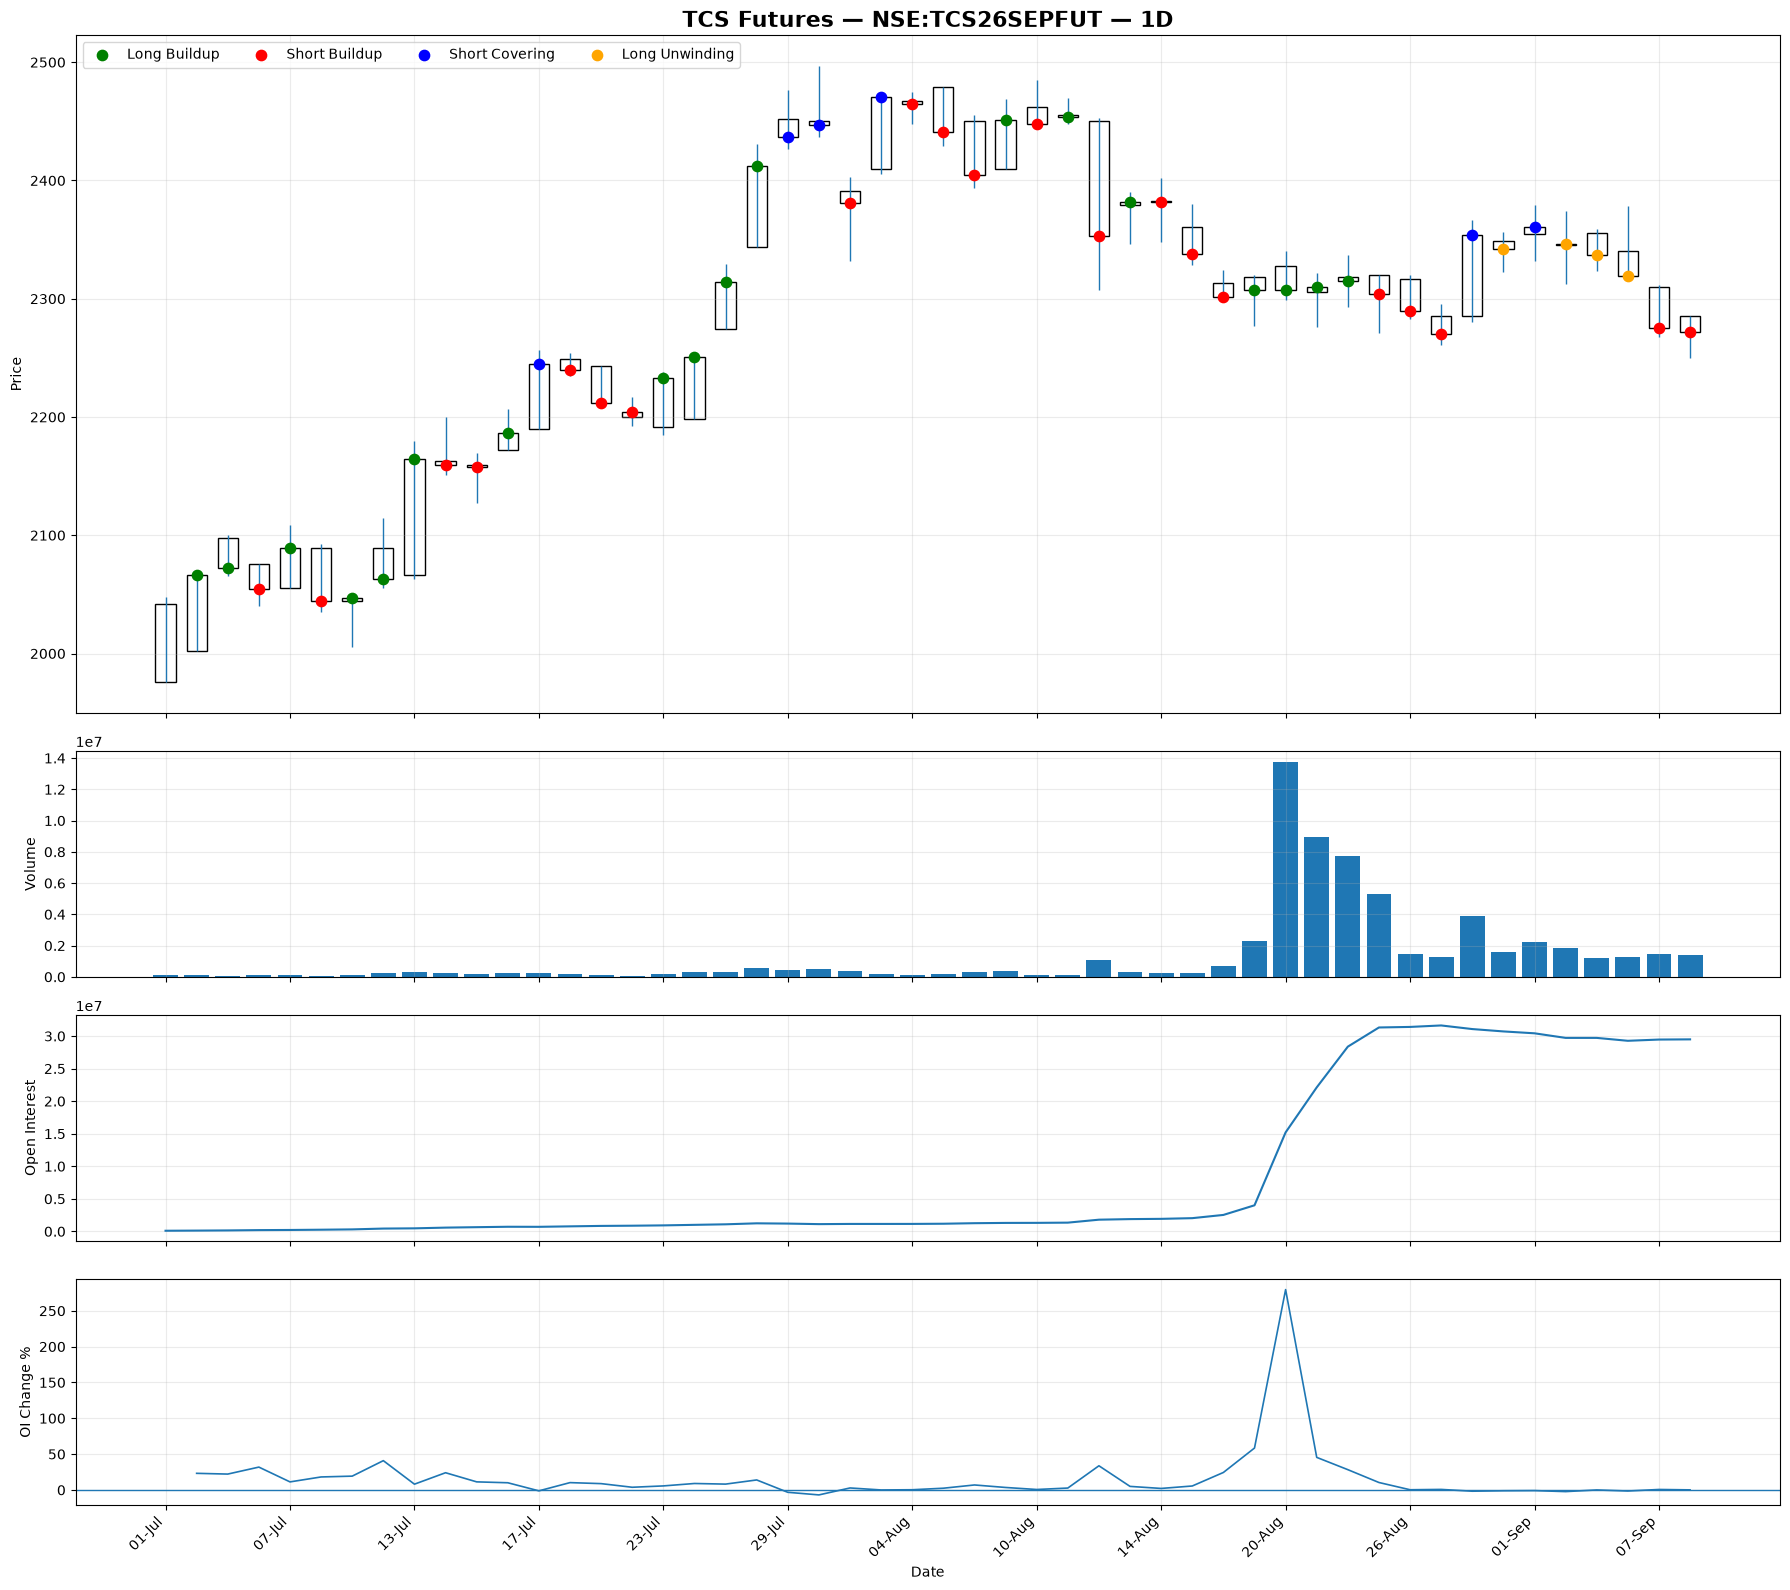

In [16]:
#12 ============================================================
# STOCK FUTURES DASHBOARD
# ============================================================

from matplotlib.patches import Rectangle

fig, axes = plt.subplots(
    4, 1,
    figsize=(18, 16),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1, 1, 1]
    }
)

x = np.arange(len(tf_analysis))

# ============================================================
# 1. CANDLESTICK PRICE CHART
# ============================================================

ax = axes[0]

candle_width = 0.65

for i, row in tf_analysis.iterrows():

    # Candle body
    body_low = min(
        row["open"],
        row["close"]
    )

    body_height = abs(
        row["close"] -
        row["open"]
    )

    # Wick
    ax.vlines(
        i,
        row["low"],
        row["high"],
        linewidth=1
    )

    # Avoid zero-height rectangle
    if body_height == 0:
        body_height = 0.01

    rect = Rectangle(
        (
            i - candle_width / 2,
            body_low
        ),
        candle_width,
        body_height,
        fill=False,
        linewidth=1
    )

    ax.add_patch(rect)

# ============================================================
# POSITION DOTS
# ============================================================

position_colors = {
    "Long Buildup": "green",
    "Short Buildup": "red",
    "Short Covering": "blue",
    "Long Unwinding": "orange"
}

position_labels = {
    "Long Buildup": "Long Buildup",
    "Short Buildup": "Short Buildup",
    "Short Covering": "Short Covering",
    "Long Unwinding": "Long Unwinding"
}

for position, color in position_colors.items():

    mask = (
        tf_analysis["position"] == position
    )

    ax.scatter(
        x[mask],
        tf_analysis.loc[mask, "close"],
        s=55,
        color=color,
        label=position_labels[position],
        zorder=5
    )

# ============================================================
# PRICE PANEL
# ============================================================

ax.set_title(
    f"{selected_stock} Futures — "
    f"{selected_symbol} — "
    f"{selected_timeframe}",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Price")

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="upper left",
    ncol=4
)

# ============================================================
# 2. VOLUME
# ============================================================

axes[1].bar(
    x,
    tf_analysis["volume"],
    width=0.8
)

axes[1].set_ylabel("Volume")

axes[1].grid(
    True,
    alpha=0.25
)

# ============================================================
# 3. OPEN INTEREST
# ============================================================

axes[2].plot(
    x,
    tf_analysis["open_interest"],
    linewidth=1.5
)

axes[2].set_ylabel("Open Interest")

axes[2].grid(
    True,
    alpha=0.25
)

# ============================================================
# 4. OI CHANGE %
# ============================================================

axes[3].plot(
    x,
    tf_analysis["oi_change_pct"],
    linewidth=1.2
)

axes[3].axhline(
    0,
    linewidth=1
)

axes[3].set_ylabel("OI Change %")

axes[3].grid(
    True,
    alpha=0.25
)

# ============================================================
# X-AXIS
# ============================================================

step = max(
    1,
    len(tf_analysis) // 12
)

tick_positions = x[::step]

tick_labels = (
    tf_analysis["datetime"]
    .dt.strftime("%d-%b")
    .iloc[::step]
)

axes[3].set_xticks(
    tick_positions
)

axes[3].set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right"
)

axes[3].set_xlabel("Date")

plt.tight_layout()

plt.show()

In [17]:
# 13============================================================
# CHECK SELECTION
# ============================================================

required_variables = [
    "selected_stock",
    "analysis_mode",
    "selected_timeframe"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Selection is not initialized. "
        "Please run the STOCK FUTURES ANALYSIS SELECTOR cell first."
    )

In [18]:
#14 ============================================================
# RESAMPLE SELECTED STOCK FUTURES
# INDIVIDUAL / CUMULATIVE
# ============================================================

stock_data = df[
    df["stock"] == selected_stock
].copy()

stock_data["expiry"] = pd.to_datetime(
    stock_data["expiry"]
).dt.date

# ============================================================
# INDIVIDUAL CONTRACT
# ============================================================

if analysis_mode == "Individual":

    selected_data = stock_data[
        (stock_data["symbol"] == selected_symbol) &
        (stock_data["expiry"] == selected_expiry)
    ].copy()

    selected_data = selected_data.sort_values(
        "datetime"
    ).set_index("datetime")

    if selected_timeframe in ["1D", "1W"]:

        resampled = (
            selected_data
            .resample(selected_timeframe)
            .agg({
                "open": "first",
                "high": "max",
                "low": "min",
                "close": "last",
                "volume": "sum",
                "open_interest": "last"
            })
        )

    else:

        resampled = (
            selected_data
            .resample(
                selected_timeframe,
                origin="start_day",
                offset="9h15min"
            )
            .agg({
                "open": "first",
                "high": "max",
                "low": "min",
                "close": "last",
                "volume": "sum",
                "open_interest": "last"
            })
        )

# ============================================================
# CUMULATIVE — CURRENT + NEXT + FAR
# ============================================================

else:

    # --------------------------------------------------------
    # Identify Current / Next / Far
    # --------------------------------------------------------

    contracts = (
        stock_data[
            ["symbol", "expiry"]
        ]
        .drop_duplicates()
        .sort_values("expiry")
        .head(3)
        .reset_index(drop=True)
    )

    current_symbol = contracts.iloc[0]["symbol"]
    current_expiry = contracts.iloc[0]["expiry"]

    # --------------------------------------------------------
    # CURRENT CONTRACT → OHLC
    # --------------------------------------------------------

    current_data = stock_data[
        (stock_data["symbol"] == current_symbol) &
        (stock_data["expiry"] == current_expiry)
    ].copy()

    current_data = current_data.set_index(
        "datetime"
    )

    if selected_timeframe in ["1D", "1W"]:

        current_resampled = (
            current_data
            .resample(selected_timeframe)
            .agg({
                "open": "first",
                "high": "max",
                "low": "min",
                "close": "last"
            })
        )

    else:

        current_resampled = (
            current_data
            .resample(
                selected_timeframe,
                origin="start_day",
                offset="9h15min"
            )
            .agg({
                "open": "first",
                "high": "max",
                "low": "min",
                "close": "last"
            })
        )

    # --------------------------------------------------------
    # EACH CONTRACT SEPARATELY
    # --------------------------------------------------------

    contract_results = []

    for _, contract in contracts.iterrows():

        symbol = contract["symbol"]

        contract_data = stock_data[
            stock_data["symbol"] == symbol
        ].copy()

        contract_data = contract_data.set_index(
            "datetime"
        )

        # ----------------------------------------------------
        # RESAMPLE CONTRACT
        # ----------------------------------------------------

        if selected_timeframe in ["1D", "1W"]:

            contract_resampled = (
                contract_data
                .resample(selected_timeframe)
                .agg({
                    "volume": "sum",
                    "open_interest": "last"
                })
            )

        else:

            contract_resampled = (
                contract_data
                .resample(
                    selected_timeframe,
                    origin="start_day",
                    offset="9h15min"
                )
                .agg({
                    "volume": "sum",
                    "open_interest": "last"
                })
            )

        contract_results.append(
            contract_resampled
        )

    # --------------------------------------------------------
    # ADD CONTRACTS TOGETHER
    # --------------------------------------------------------

    cumulative_resampled = pd.concat(
        contract_results,
        axis=1
    )

    # --------------------------------------------------------
    # SUM VOLUME AND OI ACROSS CONTRACTS
    # --------------------------------------------------------

    volume_columns = [
        col
        for col in cumulative_resampled.columns
        if col == "volume"
    ]

    oi_columns = [
        col
        for col in cumulative_resampled.columns
        if col == "open_interest"
    ]

    cumulative_volume = (
        cumulative_resampled[
            volume_columns
        ]
        .sum(axis=1, min_count=1)
    )

    cumulative_oi = (
        cumulative_resampled[
            oi_columns
        ]
        .sum(axis=1, min_count=1)
    )

    # --------------------------------------------------------
    # COMBINE CURRENT PRICE + CUMULATIVE OI/VOLUME
    # --------------------------------------------------------

    resampled = current_resampled.copy()

    resampled["volume"] = cumulative_volume

    resampled["open_interest"] = cumulative_oi

# ============================================================
# REMOVE EMPTY PRICE CANDLES
# ============================================================

resampled = resampled.dropna(
    subset=[
        "open",
        "high",
        "low",
        "close"
    ]
)

# ============================================================
# INTRADAY SESSION FILTER
# ============================================================

if selected_timeframe not in ["1D", "1W"]:

    resampled = resampled[
        (
            resampled.index.time >=
            pd.Timestamp("09:15").time()
        )
        &
        (
            resampled.index.time <=
            pd.Timestamp("15:30").time()
        )
    ]

# ============================================================
# RESET INDEX
# ============================================================

resampled = resampled.reset_index()

# ============================================================
# DISPLAY
# ============================================================

print("=" * 60)
print("RESAMPLED STOCK FUTURES DATA")
print("=" * 60)

print("Stock     :", selected_stock)
print("Mode      :", analysis_mode)
print("Timeframe :", selected_timeframe)

if analysis_mode == "Individual":

    print("Contract  :", selected_symbol)

else:

    print("Price     :", current_symbol)
    print("OI/Volume : Current + Next + Far")

print()
print("Candles:", len(resampled))

print(
    "Start:",
    resampled["datetime"].min()
)

print(
    "End  :",
    resampled["datetime"].max()
)

print()
print("Recent cumulative data:")

print(
    resampled[
        [
            "datetime",
            "close",
            "volume",
            "open_interest"
        ]
    ].tail(10)
)

RESAMPLED STOCK FUTURES DATA
Stock     : TCS
Mode      : Individual
Timeframe : 1D
Contract  : NSE:TCS26SEPFUT

Candles: 0
Start: NaT
End  : NaT

Recent cumulative data:
Empty DataFrame
Columns: [datetime, close, volume, open_interest]
Index: []


In [19]:
#15 ============================================================
# TIMEFRAME F&O ANALYSIS
# INDIVIDUAL / CUMULATIVE
# ============================================================

tf_analysis = resampled.copy()

# ------------------------------------------------------------
# PREVIOUS CLOSE
# ------------------------------------------------------------

tf_analysis["prev_close"] = (
    tf_analysis["close"].shift(1)
)

# ------------------------------------------------------------
# VALID OI
# ------------------------------------------------------------

tf_analysis["valid_oi"] = (
    tf_analysis["open_interest"]
    .where(tf_analysis["open_interest"] > 0)
)

tf_analysis["prev_oi"] = (
    tf_analysis["valid_oi"].shift(1)
)

# ------------------------------------------------------------
# PRICE CHANGE
# ------------------------------------------------------------

tf_analysis["price_change"] = (
    tf_analysis["close"]
    - tf_analysis["prev_close"]
)

tf_analysis["price_change_pct"] = (
    tf_analysis["price_change"]
    / tf_analysis["prev_close"]
    * 100
)

# ------------------------------------------------------------
# OI CHANGE
# ------------------------------------------------------------

tf_analysis["oi_change"] = (
    tf_analysis["valid_oi"]
    - tf_analysis["prev_oi"]
)

tf_analysis["oi_change_pct"] = (
    tf_analysis["oi_change"]
    / tf_analysis["prev_oi"]
    * 100
)

# ------------------------------------------------------------
# POSITION CLASSIFICATION
# ------------------------------------------------------------

def classify_position(row):

    price_change = row["price_change"]
    oi_change = row["oi_change"]

    if pd.isna(oi_change):
        return "No OI Data"

    if price_change > 0 and oi_change > 0:
        return "Long Buildup"

    elif price_change < 0 and oi_change > 0:
        return "Short Buildup"

    elif price_change > 0 and oi_change < 0:
        return "Short Covering"

    elif price_change < 0 and oi_change < 0:
        return "Long Unwinding"

    else:
        return "Neutral"


tf_analysis["position"] = (
    tf_analysis.apply(
        classify_position,
        axis=1
    )
)

# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("F&O POSITION ANALYSIS")
print("=" * 60)

print("Stock     :", selected_stock)
print("Mode      :", analysis_mode)
print("Timeframe :", selected_timeframe)

if analysis_mode == "Individual":
    print("Contract  :", selected_symbol)

else:
    print("Contracts : Current + Next + Far")
    print("Price     :", current_symbol)

print()
print("Position summary:")
print(
    tf_analysis["position"].value_counts()
)

print()
print("Recent analysis:")

print(
    tf_analysis[
        [
            "datetime",
            "close",
            "volume",
            "open_interest",
            "price_change_pct",
            "oi_change_pct",
            "position"
        ]
    ].tail(15)
)

F&O POSITION ANALYSIS
Stock     : TCS
Mode      : Individual
Timeframe : 1D
Contract  : NSE:TCS26SEPFUT

Position summary:
Series([], Name: count, dtype: int64)

Recent analysis:
Empty DataFrame
Columns: [datetime, close, volume, open_interest, price_change_pct, oi_change_pct, position]
Index: []


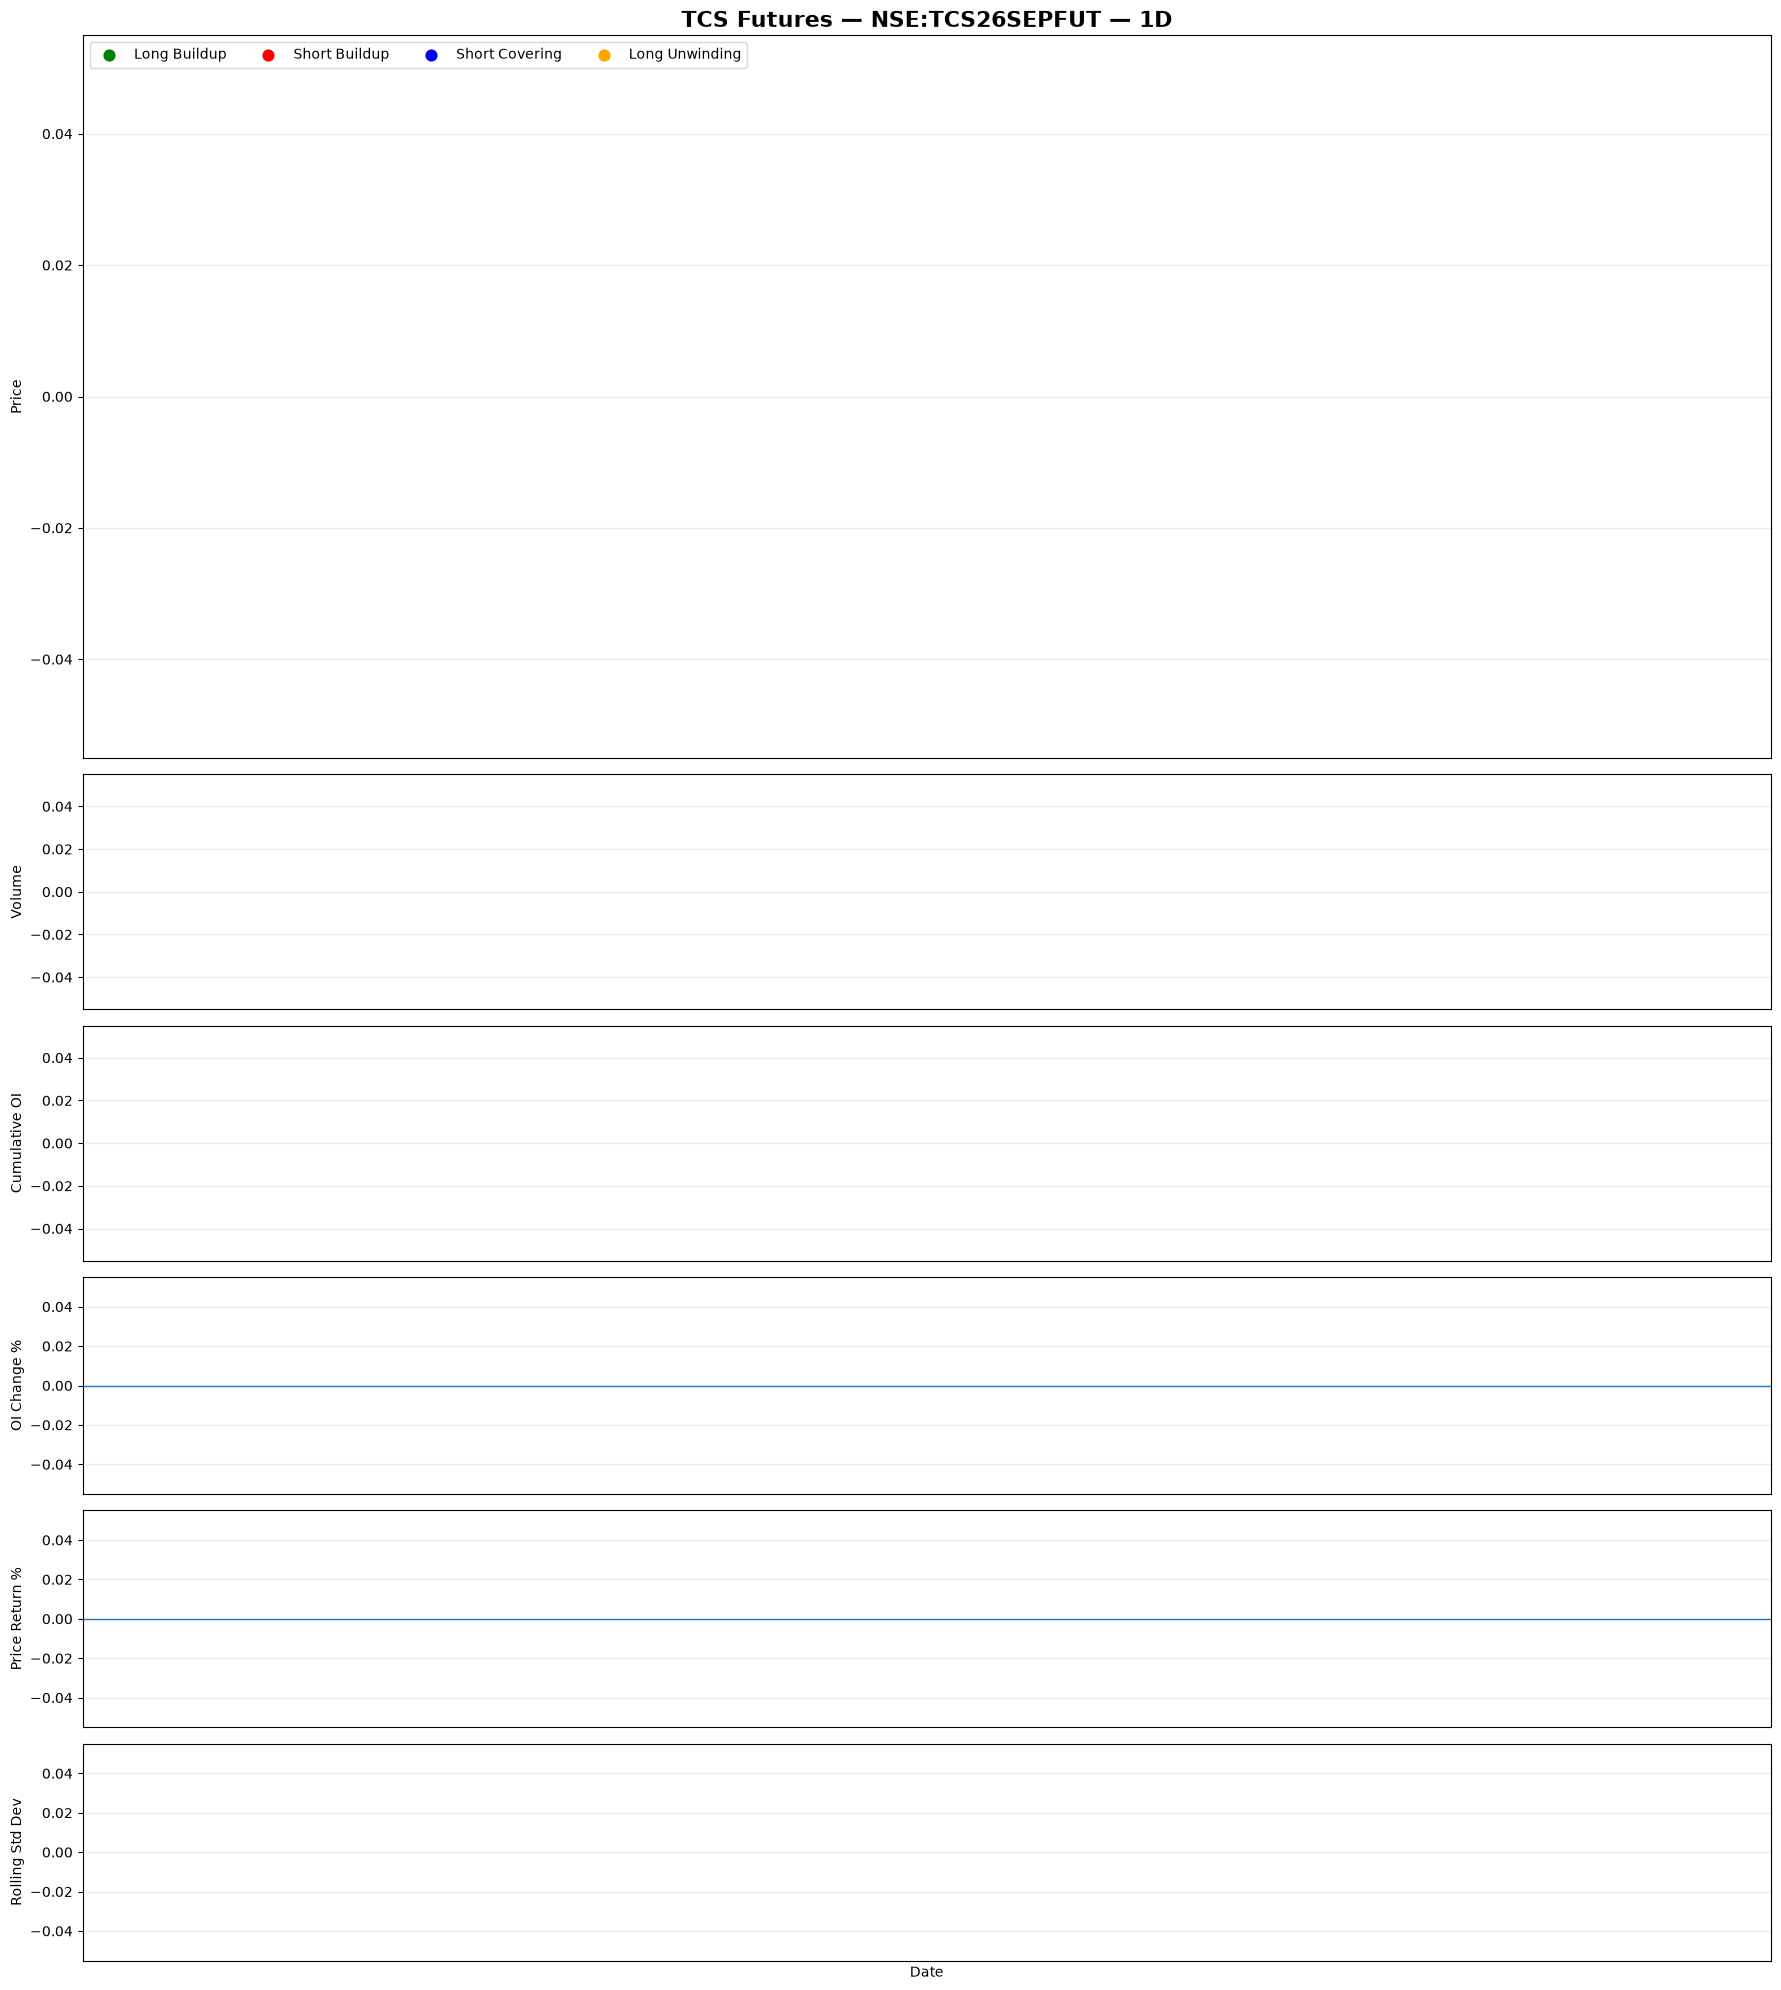

In [20]:
#16 ============================================================
# FINAL STOCK FUTURES DASHBOARD
# ============================================================

from matplotlib.patches import Rectangle

# ------------------------------------------------------------
# ADD ANALYTICS
# ------------------------------------------------------------

tf_analysis["price_return_pct"] = (
    tf_analysis["close"]
    .pct_change()
    * 100
)

# Rolling standard deviation of returns
tf_analysis["rolling_std"] = (
    tf_analysis["price_return_pct"]
    .rolling(10)
    .std()
)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    6,
    1,
    figsize=(18, 20),
    sharex=True,
    gridspec_kw={
        "height_ratios": [
            4,
            1.3,
            1.3,
            1.2,
            1.2,
            1.2
        ]
    }
)

x = np.arange(len(tf_analysis))

# ============================================================
# 1. PRICE / CANDLESTICK
# ============================================================

ax = axes[0]

candle_width = 0.65

for i, row in tf_analysis.iterrows():

    # --------------------------------------------
    # Wick
    # --------------------------------------------

    ax.vlines(
        i,
        row["low"],
        row["high"],
        linewidth=1
    )

    # --------------------------------------------
    # Body
    # --------------------------------------------

    body_low = min(
        row["open"],
        row["close"]
    )

    body_height = abs(
        row["close"]
        - row["open"]
    )

    if body_height == 0:
        body_height = 0.01

    rect = Rectangle(
        (
            i - candle_width / 2,
            body_low
        ),
        candle_width,
        body_height,
        fill=False,
        linewidth=1
    )

    ax.add_patch(rect)

# ============================================================
# POSITION DOTS
# ============================================================

position_colors = {
    "Long Buildup": "green",
    "Short Buildup": "red",
    "Short Covering": "blue",
    "Long Unwinding": "orange"
}

for position, color in position_colors.items():

    mask = (
        tf_analysis["position"] == position
    )

    ax.scatter(
        x[mask],
        tf_analysis.loc[
            mask,
            "close"
        ],
        s=60,
        color=color,
        label=position,
        zorder=5
    )

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

if analysis_mode == "Cumulative":

    title = (
        f"{selected_stock} Futures — "
        f"CUMULATIVE — "
        f"{selected_timeframe}"
    )

else:

    title = (
        f"{selected_stock} Futures — "
        f"{selected_symbol} — "
        f"{selected_timeframe}"
    )

ax.set_title(
    title,
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Price")

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="upper left",
    ncol=4
)

# ============================================================
# 2. VOLUME
# ============================================================

axes[1].bar(
    x,
    tf_analysis["volume"],
    width=0.8
)

axes[1].set_ylabel(
    "Volume"
)

axes[1].grid(
    True,
    alpha=0.25
)

# ============================================================
# 3. CUMULATIVE OI
# ============================================================

axes[2].plot(
    x,
    tf_analysis["open_interest"],
    linewidth=1.5
)

axes[2].set_ylabel(
    "Cumulative OI"
)

axes[2].grid(
    True,
    alpha=0.25
)

# ============================================================
# 4. OI CHANGE %
# ============================================================

axes[3].plot(
    x,
    tf_analysis["oi_change_pct"],
    linewidth=1.2
)

axes[3].axhline(
    0,
    linewidth=1
)

axes[3].set_ylabel(
    "OI Change %"
)

axes[3].grid(
    True,
    alpha=0.25
)

# ============================================================
# 5. PRICE RETURN %
# ============================================================

axes[4].plot(
    x,
    tf_analysis["price_return_pct"],
    linewidth=1.2
)

axes[4].axhline(
    0,
    linewidth=1
)

axes[4].set_ylabel(
    "Price Return %"
)

axes[4].grid(
    True,
    alpha=0.25
)

# ============================================================
# 6. ROLLING STANDARD DEVIATION
# ============================================================

axes[5].plot(
    x,
    tf_analysis["rolling_std"],
    linewidth=1.2
)

axes[5].set_ylabel(
    "Rolling Std Dev"
)

axes[5].set_xlabel(
    "Date"
)

axes[5].grid(
    True,
    alpha=0.25
)

# ============================================================
# X-AXIS
# ============================================================

step = max(
    1,
    len(tf_analysis) // 12
)

tick_positions = x[::step]

tick_labels = (
    tf_analysis["datetime"]
    .dt.strftime("%d-%b")
    .iloc[::step]
)

axes[5].set_xticks(
    tick_positions
)

axes[5].set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right"
)

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

In [21]:
#17 ============================================================
# LATEST F&O STATUS SUMMARY
# ============================================================

latest = tf_analysis.iloc[-1]

position = latest["position"]

position_symbol = {
    "Long Buildup": "🟢",
    "Short Buildup": "🔴",
    "Short Covering": "🔵",
    "Long Unwinding": "🟠",
    "Neutral": "⚪",
    "No OI Data": "⚪"
}

print()
print("=" * 60)
print(
    f"{selected_stock} — "
    f"{analysis_mode.upper()} FUTURES ANALYSIS"
)
print("=" * 60)

print()
print(
    f"Latest Date       : "
    f"{latest['datetime'].strftime('%d-%b-%Y')}"
)

print(
    f"Current Price     : "
    f"{latest['close']:.2f}"
)

print(
    f"Volume            : "
    f"{latest['volume']:,.0f}"
)

print(
    f"Cumulative OI     : "
    f"{latest['open_interest']:,.0f}"
)

print(
    f"OI Change         : "
    f"{latest['oi_change_pct']:.2f}%"
)

print(
    f"Price Return      : "
    f"{latest['price_return_pct']:.2f}%"
)

print(
    f"Latest Position   : "
    f"{position_symbol.get(position, '')} {position}"
)

print()
print("-" * 60)
print("SIGNAL COUNTS")
print("-" * 60)

signal_counts = (
    tf_analysis["position"]
    .value_counts()
)

for signal in [
    "Long Buildup",
    "Short Buildup",
    "Short Covering",
    "Long Unwinding",
    "Neutral",
    "No OI Data"
]:

    count = signal_counts.get(
        signal,
        0
    )

    if count > 0:

        print(
            f"{position_symbol.get(signal, '')} "
            f"{signal:<18} : {count}"
        )

print("=" * 60)

IndexError: single positional indexer is out-of-bounds

In [22]:
# 18============================================================
# NEXT-PERIOD EMPIRICAL PROBABILITY
# ============================================================

prob_data = tf_analysis.copy()

# ------------------------------------------------------------
# TIMEFRAME-BASED MOVE THRESHOLD
# ------------------------------------------------------------

move_thresholds = {
    "5min": 0.15,
    "15min": 0.25,
    "30min": 0.35,
    "1h": 0.50,
    "4h": 0.75,
    "1D": 0.50,
    "1W": 1.00
}

threshold = move_thresholds[selected_timeframe]

# ------------------------------------------------------------
# NEXT PERIOD RETURN
# ------------------------------------------------------------

prob_data["next_return_pct"] = (
    prob_data["close"]
    .shift(-1)
    .div(prob_data["close"])
    .sub(1)
    * 100
)

# ------------------------------------------------------------
# CLASSIFY NEXT PERIOD
# ------------------------------------------------------------

def classify_next_move(return_pct):

    if pd.isna(return_pct):
        return np.nan

    if return_pct > threshold:
        return "Upside"

    elif return_pct < -threshold:
        return "Downside"

    else:
        return "Sideways"


prob_data["next_move"] = (
    prob_data["next_return_pct"]
    .apply(classify_next_move)
)

# ------------------------------------------------------------
# REMOVE LAST ROW
# ------------------------------------------------------------

historical_moves = prob_data.dropna(
    subset=["next_move"]
).copy()

# ------------------------------------------------------------
# OVERALL PROBABILITY
# ------------------------------------------------------------

probability = (
    historical_moves["next_move"]
    .value_counts(normalize=True)
    * 100
)

upside_probability = probability.get(
    "Upside",
    0
)

downside_probability = probability.get(
    "Downside",
    0
)

sideways_probability = probability.get(
    "Sideways",
    0
)

# ------------------------------------------------------------
# CURRENT POSITION CONDITIONAL PROBABILITY
# ------------------------------------------------------------

current_position = (
    tf_analysis.iloc[-1]["position"]
)

conditional_data = historical_moves[
    historical_moves["position"]
    == current_position
].copy()

conditional_probability = (
    conditional_data["next_move"]
    .value_counts(normalize=True)
    * 100
)

conditional_upside = conditional_probability.get(
    "Upside",
    0
)

conditional_downside = conditional_probability.get(
    "Downside",
    0
)

conditional_sideways = conditional_probability.get(
    "Sideways",
    0
)

# ============================================================
# DISPLAY
# ============================================================

print("=" * 60)
print("NEXT-PERIOD EMPIRICAL PROBABILITY")
print("=" * 60)

print(
    f"Stock     : {selected_stock}"
)

print(
    f"Mode      : {analysis_mode}"
)

print(
    f"Timeframe : {selected_timeframe}"
)

print(
    f"Move threshold : ±{threshold:.2f}%"
)

print()
print("OVERALL HISTORICAL PROBABILITY")
print("-" * 60)

print(
    f"Upside       : {upside_probability:.1f}%"
)

print(
    f"Sideways     : {sideways_probability:.1f}%"
)

print(
    f"Downside     : {downside_probability:.1f}%"
)

print(
    f"Observations : {len(historical_moves)}"
)

print()
print(
    f"CURRENT STATE: {current_position}"
)

print("-" * 60)

print(
    f"Upside       : {conditional_upside:.1f}%"
)

print(
    f"Sideways     : {conditional_sideways:.1f}%"
)

print(
    f"Downside     : {conditional_downside:.1f}%"
)

print(
    f"Matching historical cases: "
    f"{len(conditional_data)}"
)

print("=" * 60)

IndexError: single positional indexer is out-of-bounds